In [580]:
from prepare_output_file import collect_json_files
from utils import load_json, save_json, dialogue_to_string, extract_dialogue
from tqdm import tqdm
import dotenv

In [581]:
dev_predictions = collect_json_files("experiment_fs/output_dev/")
dev_truth = load_json("data/source/mrbench_v3_devset.json")

In [582]:
dev_predictions_ids = [i['conversation_id'] for i in dev_predictions]

In [583]:
target_ids = dev_predictions_ids[0]

yh = [p for p in dev_predictions if p['conversation_id'] == target_ids][0]
y = [truth for truth in dev_truth if truth['conversation_id'] == target_ids][0]

print(target_ids)

3661-2ccdff5e-64ca-4a86-9c5e-d9406a11ec66


In [584]:
dialogue = dialogue_to_string(extract_dialogue(y["conversation_history"]))
print(dialogue)

- Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: The dog toys Samantha buys for her dog are "buy one get one half off" and all cost $12.00 each. She buys 4 toys.  How much does she spend on dog toys?
- Student: Samantha buys 4 toys at $12.00 each.
For each pair of toys, she gets one at full price and one at half price.
So she pays for three full price toys and one half price toy.
Three full price toys cost 3 x $12.00 = $36.00.
One half price toy costs $12.00 / 2 = $6.00.
Therefore, Samantha spends $36.00 + $6.00 = $42.00 on dog toys.
 42.00
- Tutor: I added the two amounts together to get a total of $36.00 + $6.00 = $42.00.
- Tutor: How many toys will be half price?
- Student: One of the four toys will be half price so I calculated that one half price toy costs $12.00 / 2 = $6.00.


In [585]:
for tutor in y['tutor_responses']:
    response = y['tutor_responses'][tutor]['response']
    value = y['tutor_responses'][tutor]['annotation']['Mistake_Identification']
    predicted = yh['tutor_responses'][tutor]['annotation']['Mistake_Identification']
    print(f"--- {tutor} ---")
    print(f"response: {response}")
    print(f"Truth: {value}")
    print(f"Predicted: {predicted}")

    

--- Llama318B ---
response: That's correct, since she buys 4 toys and they are bought 2 at a time, there will be 2 sets of toys with one at full price ($12) and one at half price ($6).
Truth: No
Predicted: No
--- Sonnet ---
response: Great effort, but let's think about how many pairs of toys Samantha is buying and how that affects the number of half-priced toys.
Truth: Yes
Predicted: Yes
--- Gemini ---
response: That's a great start, but remember that for every **two** toys Samantha buys, one is half price. 
Truth: Yes
Predicted: Yes
--- Phi3 ---
response: To find the half-price toy, divide the original price by 2.
Truth: No
Predicted: To some extent
--- Expert ---
response: If she buys 4 toys then 2 will be half price. have another think
Truth: Yes
Predicted: Yes
--- GPT4 ---
response: You're on the right track, but remember that for every two toys Samantha buys, one is half off. So out of the 4 toys, 2 are at full price and 2 are at half price. Let's try recalculating with that in mi

In [586]:
def evaluate_mistake_identification_f1_multiclass(gold_data, pred_data, mode='strict', average="macro"):
    y_true = []
    y_pred = []
    tutors = []
    instances = []

    label_mapping = {
        "yes": 0,
        "to some extent": 1,
        "no": 2
    }

    inverse_label_mapping = {v: k for k, v in label_mapping.items()}

    if mode != 'strict':
        label_mapping = {
        "yes": 0,
        "to some extent": 0,
        "no":1
        }


    pred_lookup = {item['conversation_id']: item for item in pred_data}

    for gold_item in gold_data:
        conv_id = gold_item['conversation_id']
        if conv_id not in pred_lookup:
            continue

        pred_item = pred_lookup[conv_id]

        for model_name, gold_response in gold_item['tutor_responses'].items():
            if model_name not in pred_item['tutor_responses']:
                continue

            pred_response = pred_item['tutor_responses'][model_name]

            gold_label = gold_response['annotation']['Mistake_Identification'].strip().lower()
            pred_label = pred_response['annotation']['Mistake_Identification'].strip().lower()

            if gold_label in label_mapping and pred_label in label_mapping:
                y_true.append(label_mapping[gold_label])
                y_pred.append(label_mapping[pred_label])
                tutors.append(model_name)
                instances.append({
                    'conversation_id': conv_id,
                    'model_name': model_name,
                    'gold_label': gold_label,
                    'pred_label': pred_label
                })

    if not y_true:
        print("No matching predictions found.")
        return 0.0
    return y_true, y_pred, tutors, instances

y_true, y_pred, tutors, instances = evaluate_mistake_identification_f1_multiclass(dev_truth, dev_predictions, average="macro")

In [587]:
label_mapping = {
    "yes": 0,
    "to some extent": 1,
    "no": 2
}

inverse_label_mapping = {v: k for k, v in label_mapping.items()}

tutors_evaluated = {}
filtered_instances = []

c = 0

for i,j,k in zip(y_true, y_pred, tutors):
    if inverse_label_mapping[i] != inverse_label_mapping[j]:
        filtered_instances.append({
            'conversation_id': instances[c]['conversation_id'],
            'model_name': instances[c]['model_name'],
            'gold_label': inverse_label_mapping[i],
            'pred_label': inverse_label_mapping[j]
        })
        if k not in tutors_evaluated:
            tutors_evaluated[k] = [(inverse_label_mapping[i], inverse_label_mapping[j])]
        else:
            tutors_evaluated[k].append((inverse_label_mapping[i], inverse_label_mapping[j]))
    c += 1

In [588]:
tutors_evaluated

{'Sonnet': [('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('no', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent')],
 'Mistral': [('yes', 'to some extent'), ('yes', 'to some extent')],
 'Llama318B': [('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'no'),
  ('no', 'yes')],
 'Novice': [('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent')],
 'Phi3': [('no', 'yes'),
  ('yes', 'no'),
  ('no', 'to some extent'),
  ('yes', 'to some extent')],
 'Expert': [('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'no'),
  ('yes', 'to some extent'),
  ('no', 'to some extent'),
  ('yes', 'no'),
  ('yes', 'to some extent'),
  ('to some extent', 'yes'),
  ('yes', 'to some exten

In [589]:
# sort the instances by conversation_id
filtered_instances.sort(key=lambda x: x['conversation_id'])
filtered_instances

[{'conversation_id': '1042-d6c207d3-0fed-48b7-bcf9-915cac7be198',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '1042-d6c207d3-0fed-48b7-bcf9-915cac7be198',
  'model_name': 'Gemini',
  'gold_label': 'no',
  'pred_label': 'yes'},
 {'conversation_id': '1042-d6c207d3-0fed-48b7-bcf9-915cac7be198',
  'model_name': 'Llama318B',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '1340-aa89d11e-f7aa-46bd-83bb-88ce9b0a563c',
  'model_name': 'Llama31405B',
  'gold_label': 'to some extent',
  'pred_label': 'yes'},
 {'conversation_id': '1340-aa89d11e-f7aa-46bd-83bb-88ce9b0a563c',
  'model_name': 'Llama318B',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '1851-08ac123e-7b26-49d1-be29-5ddf0f381018',
  'model_name': 'Sonnet',
  'gold_label': 'no',
  'pred_label': 'to some extent'},
 {'conversation_id': '1851-08ac123e-7b26-49d1-be29-5ddf0f381018',
  'model_name': 'Expert',
  'gold_la

In [590]:
# classification report
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def print_classification_report(y_true, y_pred):
    # Convert the lists to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Print the classification report
    print(classification_report(y_true, y_pred, target_names=list(label_mapping.keys())))

# Print the classification report
print_classification_report(y_true, y_pred)

                precision    recall  f1-score   support

           yes       0.94      0.78      0.85       138
to some extent       0.09      0.50      0.15         6
            no       0.78      0.64      0.70        22

      accuracy                           0.75       166
     macro avg       0.60      0.64      0.57       166
  weighted avg       0.89      0.75      0.81       166



Confusion Matrix:


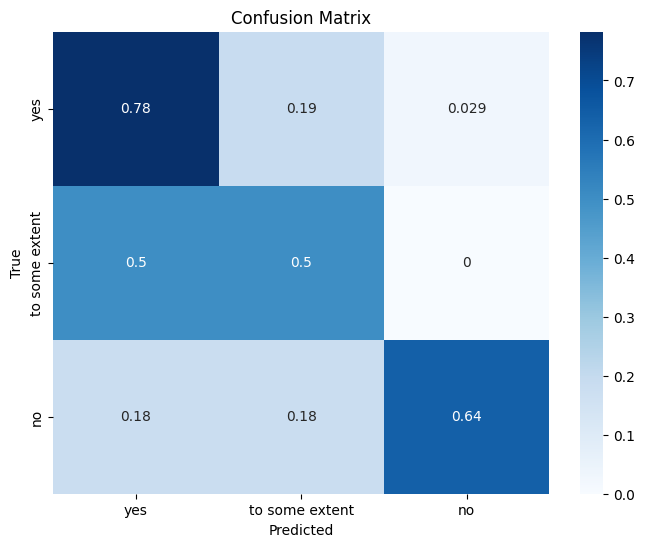

In [591]:
# plot cm matric

import matplotlib.pyplot as plt
import seaborn as sns

# Print the confusion matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')
print("Confusion Matrix:")


def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, list(label_mapping.keys()))

In [592]:
cm

array([[0.7826087 , 0.1884058 , 0.02898551],
       [0.5       , 0.5       , 0.        ],
       [0.18181818, 0.18181818, 0.63636364]])